# Pengujian Model Segmentasi & Simulasi Traffic Light Interlocking

Notebook ini menguji model segmentasi `best.pt` (YOLOv8-seg) dan mensimulasikan sistem keamanan terintegrasi:
- **DANGER**: Terdeteksi rintangan/kendaraan terjebak saat palang tertutup $\rightarrow$ **Traffic Light: KUNING lalu MERAH (STOP)**
- **SAFE**: Palang terbuka normal atau perlintasan kosong $\rightarrow$ **Traffic Light: HIJAU (AMAN)**

In [1]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Load model segmentasi terbaik
model_path = 'best.pt'
model = YOLO(model_path)

print("Model Segmentasi Berhasil Dimuat!")
print("Daftar Kelas:")
for idx, name in model.names.items():
    print(f"  [{idx}]: {name}")

Model Segmentasi Berhasil Dimuat!
Daftar Kelas:
  [0]: danger
  [1]: safe


In [2]:
def evaluate_crossing(image_path, conf_threshold=0.25):
    """
    Menjalankan inferensi segmentasi poligon dan mensimulasikan respons traffic light.
    """
    if not os.path.exists(image_path):
        print(f"File tidak ditemukan: {image_path}")
        return

    # Jalankan inferensi segmentasi
    results = model(image_path, conf=conf_threshold, verbose=False)
    result = results[0]

    detected_classes = []
    for box in result.boxes:
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        conf = float(box.conf[0])
        detected_classes.append((cls_name, round(conf, 2)))

    class_names = [c[0] for c in detected_classes]

    # Logika Sistem Traffic Light Interlocking
    if 'danger' in class_names:
        status_text = "DANGER: KENDARAAN TERJEBAK DI REL / PALANG BERMASALAH!"
        traffic_light = "[!] TRAFFIC LIGHT BELAKANG: MERAH (STOP ARUS KENDARAAN)"
        alarm_state = "[ALARM ON] Peringatan Darurat Aktif!"
        theme_color = 'red'
    elif 'safe' in class_names:
        status_text = "SAFE: JALUR AMAN"
        traffic_light = "TRAFFIC LIGHT: HIJAU (ARUS NORMAL)"
        alarm_state = "[NORMAL] Arus Lalu Lintas Berjalan Lancar"
        theme_color = 'green'
    else:
        status_text = "STANDBY: PERLINTASAN KOSONG"
        traffic_light = "TRAFFIC LIGHT: HIJAU"
        alarm_state = "[NORMAL] Siaga"
        theme_color = 'blue'

    print("=" * 65)
    print(f"Gambar        : {os.path.basename(image_path)}")
    print(f"Deteksi       : {detected_classes}")
    print(f"Status Sistem : {status_text}")
    print(f"Sinyal Lampu  : {traffic_light}")
    print(f"Status Alarm  : {alarm_state}")
    print("=" * 65)

    # Visualisasi dengan arsiran poligon segmentasi
    annotated_bgr = result.plot()  # plot() otomatis menggambar mask poligon transparan
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_rgb)
    plt.title(f"{os.path.basename(image_path)}\n{status_text} | {traffic_light}", 
              color=theme_color, fontsize=11, weight='bold')
    plt.axis('off')
    plt.show()

Menguji 3 kasus DANGER:
Gambar        : Bus_trapped_on_railway_tracks_20261005222142_jpg.rf.9nTmTw8jYu1ejrJzy7MR.jpg
Deteksi       : [('danger', 0.83), ('safe', 0.61), ('danger', 0.5), ('danger', 0.35), ('safe', 0.26)]
Status Sistem : DANGER: KENDARAAN TERJEBAK DI REL / PALANG BERMASALAH!
Sinyal Lampu  : [!] TRAFFIC LIGHT BELAKANG: MERAH (STOP ARUS KENDARAAN)
Status Alarm  : [ALARM ON] Peringatan Darurat Aktif!


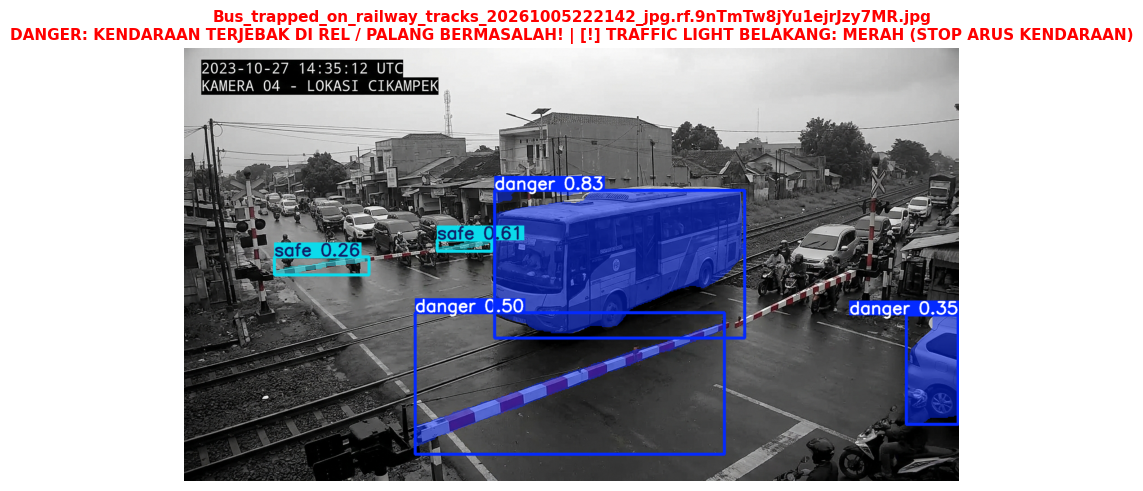

Gambar        : Bus_trapped_on_railway_tracks_20261005222143_2_jpg.rf.h1tExZz2zKmuW8TxBU7E.jpg
Deteksi       : [('danger', 0.63), ('safe', 0.42), ('safe', 0.38), ('danger', 0.3)]
Status Sistem : DANGER: KENDARAAN TERJEBAK DI REL / PALANG BERMASALAH!
Sinyal Lampu  : [!] TRAFFIC LIGHT BELAKANG: MERAH (STOP ARUS KENDARAAN)
Status Alarm  : [ALARM ON] Peringatan Darurat Aktif!


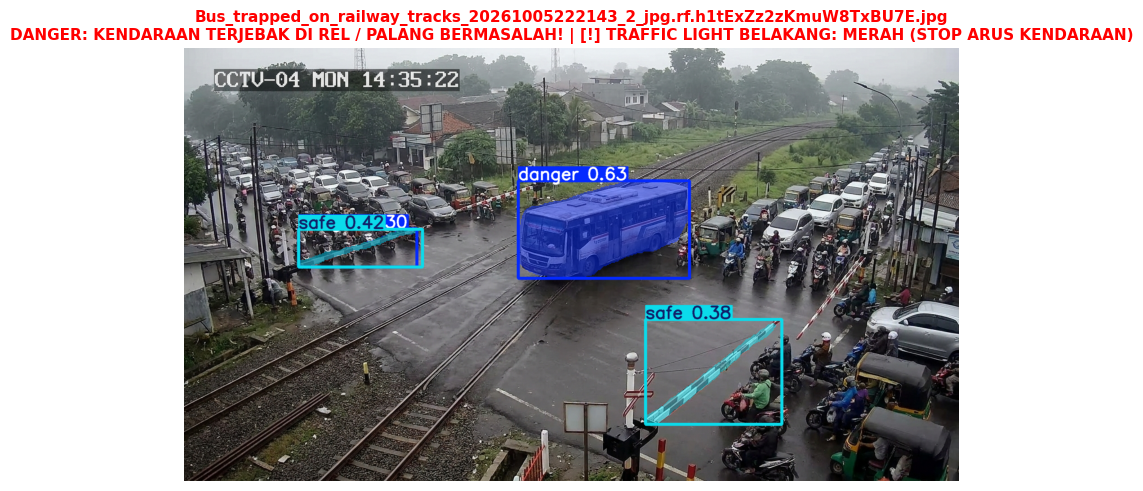

Gambar        : Bus_trapped_on_railway_tracks_20261005222143_3_jpg.rf.mBK4xhAmMm3AUqJBnYSA.jpg
Deteksi       : [('danger', 0.91), ('danger', 0.81), ('danger', 0.53), ('safe', 0.41), ('danger', 0.37)]
Status Sistem : DANGER: KENDARAAN TERJEBAK DI REL / PALANG BERMASALAH!
Sinyal Lampu  : [!] TRAFFIC LIGHT BELAKANG: MERAH (STOP ARUS KENDARAAN)
Status Alarm  : [ALARM ON] Peringatan Darurat Aktif!


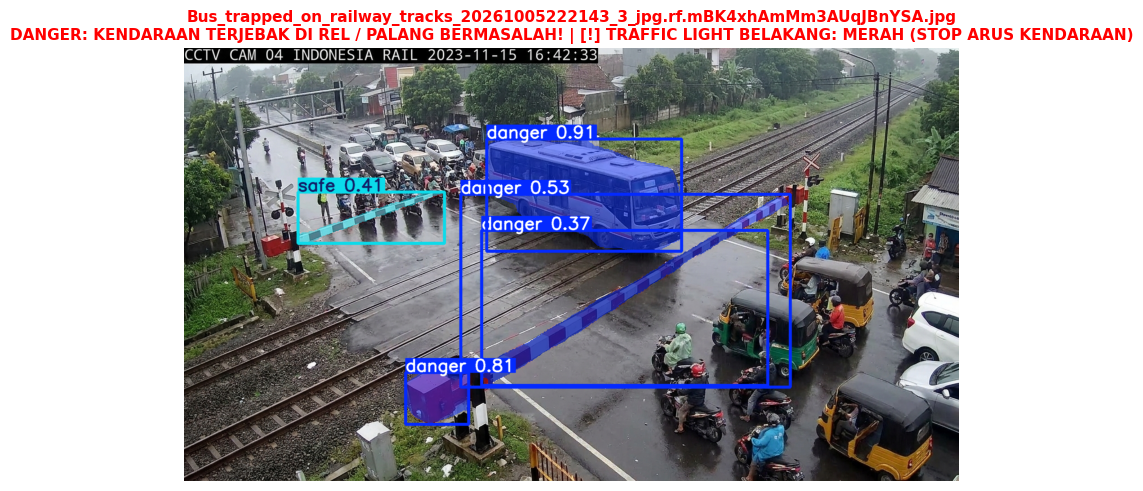

In [3]:
# Uji coba sampel kasus bus/motor terjebak (Danger Cases)
sample_dangers = glob.glob(r'datasets/dataset_tambahan/train/images/Bus_trapped*') + glob.glob(r'datasets/dataset_tambahan/train/images/Motorcycle_stuck*')

print(f"Menguji {min(3, len(sample_dangers))} kasus DANGER:")
for img in sample_dangers[:3]:
    evaluate_crossing(img)

Menguji 3 kasus SAFE:
Gambar        : Empty_railway_crossing_barrier_g…_20261005215841_jpg.rf.9AVojlo15iA1yjumQxw8.jpg
Deteksi       : [('safe', 0.83), ('safe', 0.79), ('safe', 0.65), ('safe', 0.44), ('safe', 0.34)]
Status Sistem : SAFE: JALUR AMAN
Sinyal Lampu  : TRAFFIC LIGHT: HIJAU (ARUS NORMAL)
Status Alarm  : [NORMAL] Arus Lalu Lintas Berjalan Lancar


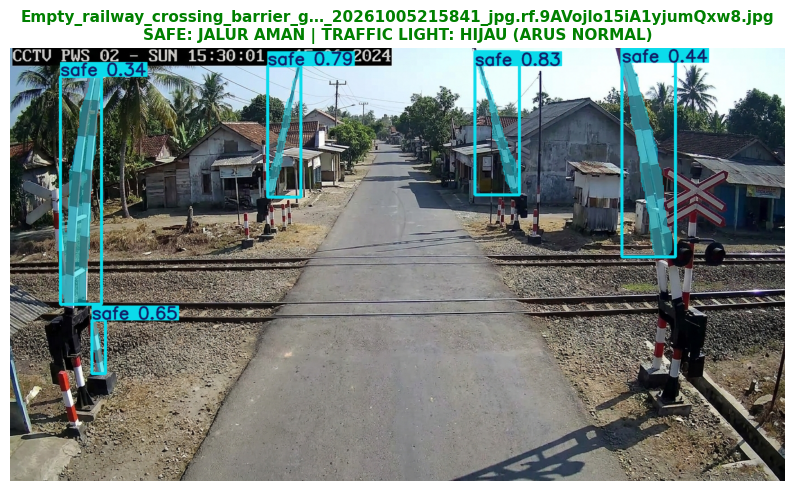

Gambar        : Motorcycles_waiting_at_railway_c…_20261005221452_2_jpg.rf.yp9xsCDQbZwawJ3zlE5x.jpg
Deteksi       : [('safe', 0.63)]
Status Sistem : SAFE: JALUR AMAN
Sinyal Lampu  : TRAFFIC LIGHT: HIJAU (ARUS NORMAL)
Status Alarm  : [NORMAL] Arus Lalu Lintas Berjalan Lancar


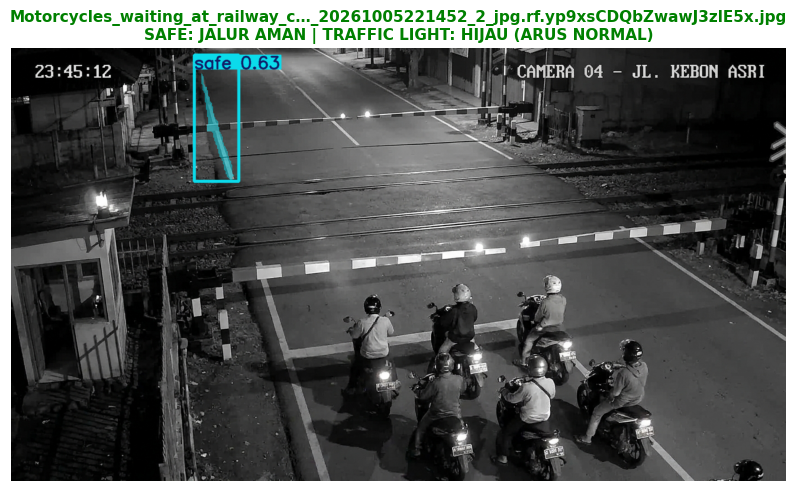

Gambar        : Motorcycles_waiting_at_railway_c…_20261005221452_jpg.rf.puVuxOhvJNNx2bZkjwq3.jpg
Deteksi       : [('safe', 0.35), ('safe', 0.27)]
Status Sistem : SAFE: JALUR AMAN
Sinyal Lampu  : TRAFFIC LIGHT: HIJAU (ARUS NORMAL)
Status Alarm  : [NORMAL] Arus Lalu Lintas Berjalan Lancar


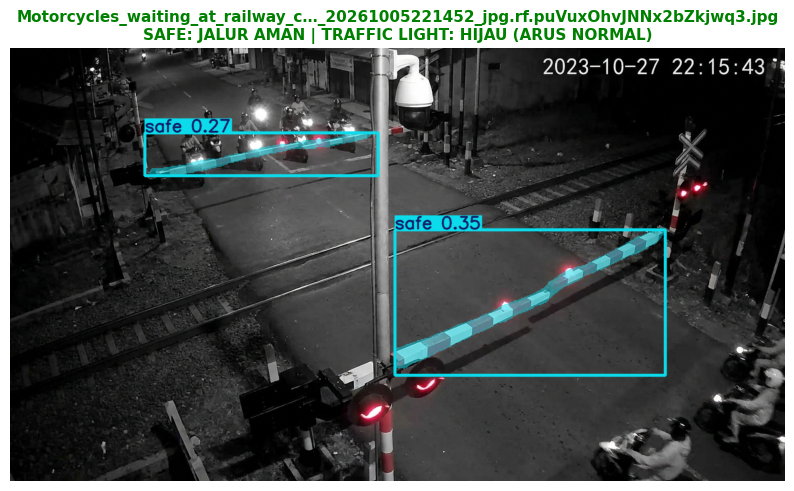

In [4]:
# Uji coba sampel kasus perlintasan kosong / aman (Safe Cases)
sample_safes = glob.glob(r'datasets/dataset_tambahan/train/images/Empty_railway*') + glob.glob(r'datasets/dataset_tambahan/train/images/Motorcycles_waiting*')

print(f"Menguji {min(3, len(sample_safes))} kasus SAFE:")
for img in sample_safes[:3]:
    evaluate_crossing(img)